# Bài tập Buổi 6 — Cây Quyết Định & Rừng Ngẫu Nhiên (Decision Tree & Random Forest)

**Sinh viên thực hiện:** "Bùi Phong Hợp"

---

## Bối cảnh

Trong bài tập này, bạn đang đóng vai trò là một Data Scientist làm việc tại một trung tâm nghiên cứu ung thư. Bạn được giao nhiệm vụ phân tích bộ dữ liệu **Breast Cancer Wisconsin (Diagnostic)**, chứa các thông số đo lường từ hình ảnh sinh thiết tế bào của các bệnh nhân.

Mục tiêu của bài toán là xây dựng mô hình học máy để phân loại khối u là **Lành tính (Benign)** hay **Ác tính (Malignant)**.

**Lưu ý quan trọng:** Trong bài toán chẩn đoán ung thư, việc chẩn đoán sót một khối u ác tính thành lành tính (False Negative) mang lại hậu quả nghiêm trọng hơn rất nhiều so với việc chẩn đoán nhầm lành tính thành ác tính (False Positive). Do đó, chúng ta sẽ đặc biệt quan tâm đến chỉ số **Recall**.

## Mục tiêu bài tập

1. Hiểu và xử lý bộ dữ liệu y khoa cơ bản với nhiều đặc trưng dạng số liên tục.
2. Huấn luyện mô hình **Decision Tree** và trực quan hóa các ranh giới quyết định (Decision Boundaries) thông qua cấu trúc cây.
3. Xây dựng mô hình **Random Forest** và đánh giá độ quan trọng của các đặc trưng (Feature Importance) trong việc chẩn đoán.
4. Phân tích chuyên sâu về các độ đo **Recall, F1-Score** và **Confusion Matrix** thay vì chỉ phụ thuộc vào Accuracy.

## Tiêu chí chấm (10 điểm)

| Task | Nội dung | Điểm |
|---|---|---|
| **1** | EDA & Thống kê dữ liệu tổng quan | 1.0 |
| **2** | Trực quan hóa tương quan dữ liệu | 2.0 |
| **3** | Chia tập & Scaling | 1.0 |
| **4** | Huấn luyện Decision Tree & Trực quan hóa cây | 2.0 |
| **5** | Huấn luyện Random Forest & Feature Importance | 2.0 |
| **6** | Đánh giá Confusion Matrix, Recall, F1-score và rút ra Insight | 2.0 |

---


## 0. Chuẩn bị môi trường & Nạp dữ liệu

Dữ liệu được tích hợp sẵn trong thư viện `scikit-learn`. Chạy ô bên dưới để tải và hiển thị.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score, f1_score

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)

# Tải dữ liệu Breast Cancer
cancer_data = load_breast_cancer()
df = pd.DataFrame(cancer_data.data, columns = cancer_data.feature_names)
df['target'] = cancer_data.target

print("Kích thước bộ dữ liệu:", df.shape)
print("Ý nghĩa Target (0: Malignant/Ác tính, 1: Benign/Lành tính):")
print(dict(zip(range(len(cancer_data.target_names)), cancer_data.target_names)))
df.head()

Kích thước bộ dữ liệu: (569, 31)
Ý nghĩa Target (0: Malignant/Ác tính, 1: Benign/Lành tính):
{0: np.str_('malignant'), 1: np.str_('benign')}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


---
## Task 1 — EDA và Kiểm tra Dữ liệu Cơ Bản

### Yêu cầu:
1. In ra số lượng mẫu dữ liệu cho từng lớp (0: Ác tính, 1: Lành tính) bằng `value_counts()`.
2. Kiểm tra xem dữ liệu có giá trị khuyết thiếu (NaN) nào không.
3. Nêu nhận xét về sự cân bằng của bộ dữ liệu.

### Gợi ý:
- Sử dụng cú pháp `df['tên_cột'].value_counts()` để đếm số lượng nhãn.
- Để kiểm tra missing value trên toàn bộ dataframe, bạn có thể kết hợp `.isnull().sum()`.

In [2]:
# TODO 1a: Đếm số lượng mẫu của từng class trong cột 'target'
sample_class_count = df['target'].value_counts()
percentage_class = df['target'].value_counts(normalize = True) * 100
print("So luong mau theo tung class")
print(sample_class_count)
print("\nPhan tram cua so phan tu thuoc mot class:")
print(percentage_class.round(3))

# TODO 1b: Kiểm tra giá trị missing
missing_value_count = df.isnull().sum()
all_mvl = missing_value_count.sum()
print("\nSo missing value theo tung dac trung:")
print(missing_value_count)
print("\nTong so missing value cua toan bo du lieu:")
print(all_mvl)

So luong mau theo tung class
target
1    357
0    212
Name: count, dtype: int64

Phan tram cua so phan tu thuoc mot class:
target
1    62.742
0    37.258
Name: proportion, dtype: float64

So missing value theo tung dac trung:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity     

**Nhận xét Task 1:**

- Bộ dữ liệu Breast Cancer Wisconsin có tổng cộng 569 mẫu: 212 mẫu thuộc lớp 0 (Ác tính - Malignant) và 357 mẫu thuộc lớp 1 (Lành tính - Benign), lần lượt tương ứng với khoảng 37.3% và 62.7% so với tổng mẫu.
- Đây là một bộ dữ liệu **mất cân bằng nhẹ**: lớp Lành tính nhiều hơn lớp Ác tính khoảng 1.68 lần.
- Toàn bộ 31 cột (gồm 30 cột đặc trưng và 1 cột target) đều không có giá trị missing value nào. Do đó, bộ dữ liệu này không cần bước xử lý missing value trước khi huấn luyện mô hình.

---
## Task 2 — Trực quan hóa Dữ liệu Y khoa

Bộ dữ liệu có tới 30 đặc trưng, chúng ta sẽ khảo sát một vài đặc trưng cơ bản.

### Yêu cầu:
1. Vẽ biểu đồ **Boxplot** so sánh phân phối của biến `mean radius` (bán kính trung bình của tế bào) giữa 2 lớp Khối u (Ác tính và Lành tính).
2. Vẽ biểu đồ **Scatter plot** giữa `mean radius` (trục x) và `mean texture` (trục y), tô màu (hue) theo cột `target`.
3. Có thể dùng 2 đặc trưng này để phân định ranh giới cơ bản giữa khối u lành/ác được không? Vì sao?

### Gợi ý:
- Vẽ Boxplot: `sns.boxplot(data=df, x='target', y='mean radius')`.
- Vẽ Scatter plot: `sns.scatterplot(data=df, x='mean radius', y='mean texture', hue='target')`.

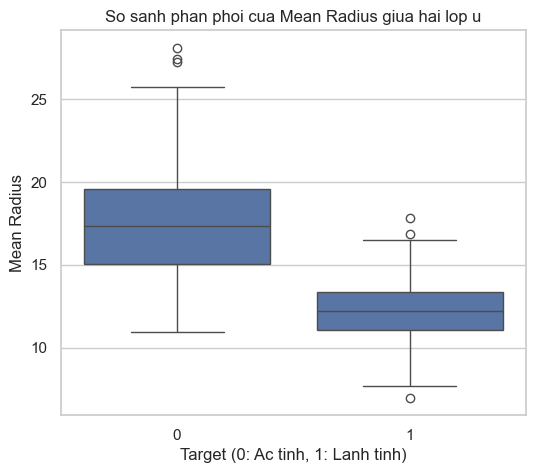

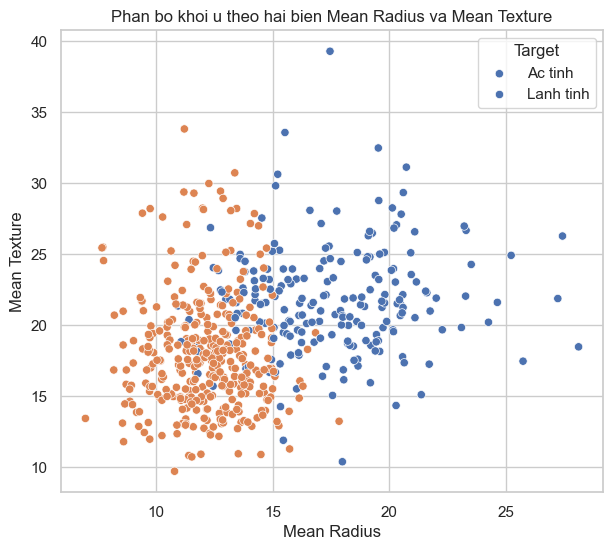

In [3]:
# TODO 2a: Boxplot cho biến 'mean radius' so với 'target'
plt.figure(figsize = (6 , 5))
sns.boxplot(data = df, x = 'target', y = 'mean radius')
plt.xlabel("Target (0: Ac tinh, 1: Lanh tinh)")
plt.ylabel("Mean Radius")
plt.title("So sanh phan phoi cua Mean Radius giua hai lop u")
plt.show()

# TODO 2b: Scatter plot giữa 'mean radius' và 'mean texture'
plt.figure(figsize = (7 , 6))
sns.scatterplot(data = df, x = 'mean radius', y = 'mean texture', hue = 'target')
plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.title("Phan bo khoi u theo hai bien Mean Radius va Mean Texture")
plt.legend(title = "Target", labels = ["Ac tinh", "Lanh tinh"])
plt.show()

**Nhận xét Task 2:**

- Từ đồ thị **Boxplot**, có thể thấy nhóm khối u **Ác tính** (target = 0) có **mean radius** (bán kính trung bình tế bào) cao hơn rõ rệt và có mức độ phân tán rộng hơn so với nhóm **Lành tính** (target = 1).
- Từ đồ thị **Scatterplot** giữa **mean radius** và **mean texture**, các điểm **Ác tính** (target = 0) tập trung ở vùng bán kính và độ đồng nhất bề mặt lớn hơn, trong khi các điểm **Lành tính** (target = 1) tập trung ở vùng bán kính nhỏ hơn.
- Tuy nhiên, ranh giới cơ bản giữa 2 lớp **không hoàn toàn tách biệt**: vẫn còn một vùng chồng lấn ở khoảng giữa (tế bào **Lành tính** nhưng có kích thước to hay tế bào **Ác tính** có kích thước chưa đủ to). Điều này có nghĩa là chỉ dùng 2 đặc trưng **mean radius** và **mean texture** vẫn có thể phân định được ranh giới **cơ bản** giữa 2 lớp, nhưng chưa đủ để phân loại chính xác hoàn toàn.

---
## Task 3 — Chia Tập Dữ Liệu và Tiền Xử Lý

### Yêu cầu:
1. Tách đặc trưng (X) và nhãn (y).
2. Chia tập Train/Test theo tỷ lệ **75/25**, `stratify=y`, và `random_state=42`.
3. Mặc dù Decision Tree và Random Forest không yêu cầu chuẩn hóa (Scaling), nhưng việc có `StandardScaler` sẽ giúp dễ dàng so sánh với các thuật toán khác (như SVM/Logistic Regression) sau này. Hãy fit `StandardScaler` trên `X_train` và transform cho cả `X_train` và `X_test`.

### Gợi ý:
- Sử dụng hàm `train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)`.
- **Nguyên tắc chống Data Leakage:** Chỉ dùng phương thức `.fit_transform()` trên tập `X_train`, nhưng chỉ được dùng phương thức `.transform()` trên tập `X_test`.

In [4]:
# TODO 3a: Tách X, y và chia train/test
X = df.drop(columns=['target'])
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, stratify = y, random_state = 42)

print("Kich thuoc tap X_train", X_train.shape)
print("Kich thuoc tap X_test", X_test.shape)

# TODO 3b: Chuẩn hóa dữ liệu bằng StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Kiểm tra X_train sau scale
X_train_scaled = pd.DataFrame(X_train_scaled, columns = X_train.columns, index = X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns = X_test.columns, index = X_test.index)
X_train_scaled.head()

Kich thuoc tap X_train (426, 30)
Kich thuoc tap X_test (143, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
517,1.659096,0.217205,1.610620,1.633339,0.576312,0.523545,0.645326,1.198745,-0.000094,-0.124425,0.414312,-0.597142,0.425168,0.497330,-0.644904,-0.138083,-0.060276,0.019795,-1.153542,-0.148977,1.567319,-0.075879,1.607223,1.384969,0.412628,0.461629,0.642584,0.701835,-0.556084,0.388781
287,-0.338165,-1.389968,-0.401667,-0.387017,-1.985604,-1.257886,-0.820500,-0.949158,-1.684127,-0.964260,-0.934201,-1.307869,-0.877182,-0.641788,-0.760951,-0.656341,-0.487169,-0.907609,-0.519211,-0.610339,-0.537720,-1.613244,-0.580788,-0.529160,-1.600400,-0.871596,-0.726165,-0.900606,-0.923646,-0.797233
25,0.874457,-0.651659,1.010370,0.761353,1.694102,2.359914,1.657179,2.389453,4.483419,1.570465,2.460083,-0.417485,2.283030,1.749826,0.308104,0.671221,0.147071,1.944061,0.258466,1.278429,1.259163,-0.683527,1.364776,1.053712,0.978433,0.856293,0.491059,2.096751,1.767211,1.165217
253,0.920109,-0.498594,0.886180,0.806211,0.358755,0.012174,0.465964,0.918425,0.039744,-0.919986,-0.340733,-0.626822,-0.324235,-0.134248,-0.752523,-0.570866,-0.279821,0.152395,-0.773169,-0.511375,0.759450,-0.098090,0.721243,0.625763,0.408208,-0.095834,0.274268,1.065079,0.345973,-0.157501
369,2.263981,0.586360,2.301943,2.408951,0.771362,1.747791,1.928079,2.649490,0.079581,-0.190837,2.315613,-0.902366,2.429218,2.205279,-1.005038,0.142144,0.099503,0.482314,-0.633210,-0.006342,2.385598,0.014555,2.639868,2.425295,-0.131075,0.816827,0.903190,1.921083,-0.262035,0.088673


---
## Task 4 — Huấn luyện Cây Quyết Định (Decision Tree)

### Yêu cầu:
1. Khởi tạo và huấn luyện `DecisionTreeClassifier(max_depth=3, random_state=42)` trên tập Train.
2. Sử dụng `plot_tree` để vẽ cấu trúc cây.
3. Nút gốc (Root Node) đang dùng đặc trưng nào để chia nhánh dữ liệu đầu tiên? Bạn có nghĩ đó là đặc trưng quan trọng nhất không?

### Gợi ý:
- Khởi tạo mô hình: `dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)`.
- Đừng quên gọi `.fit(X_train_scaled, y_train)` trước khi thực hiện vẽ sơ đồ cây.

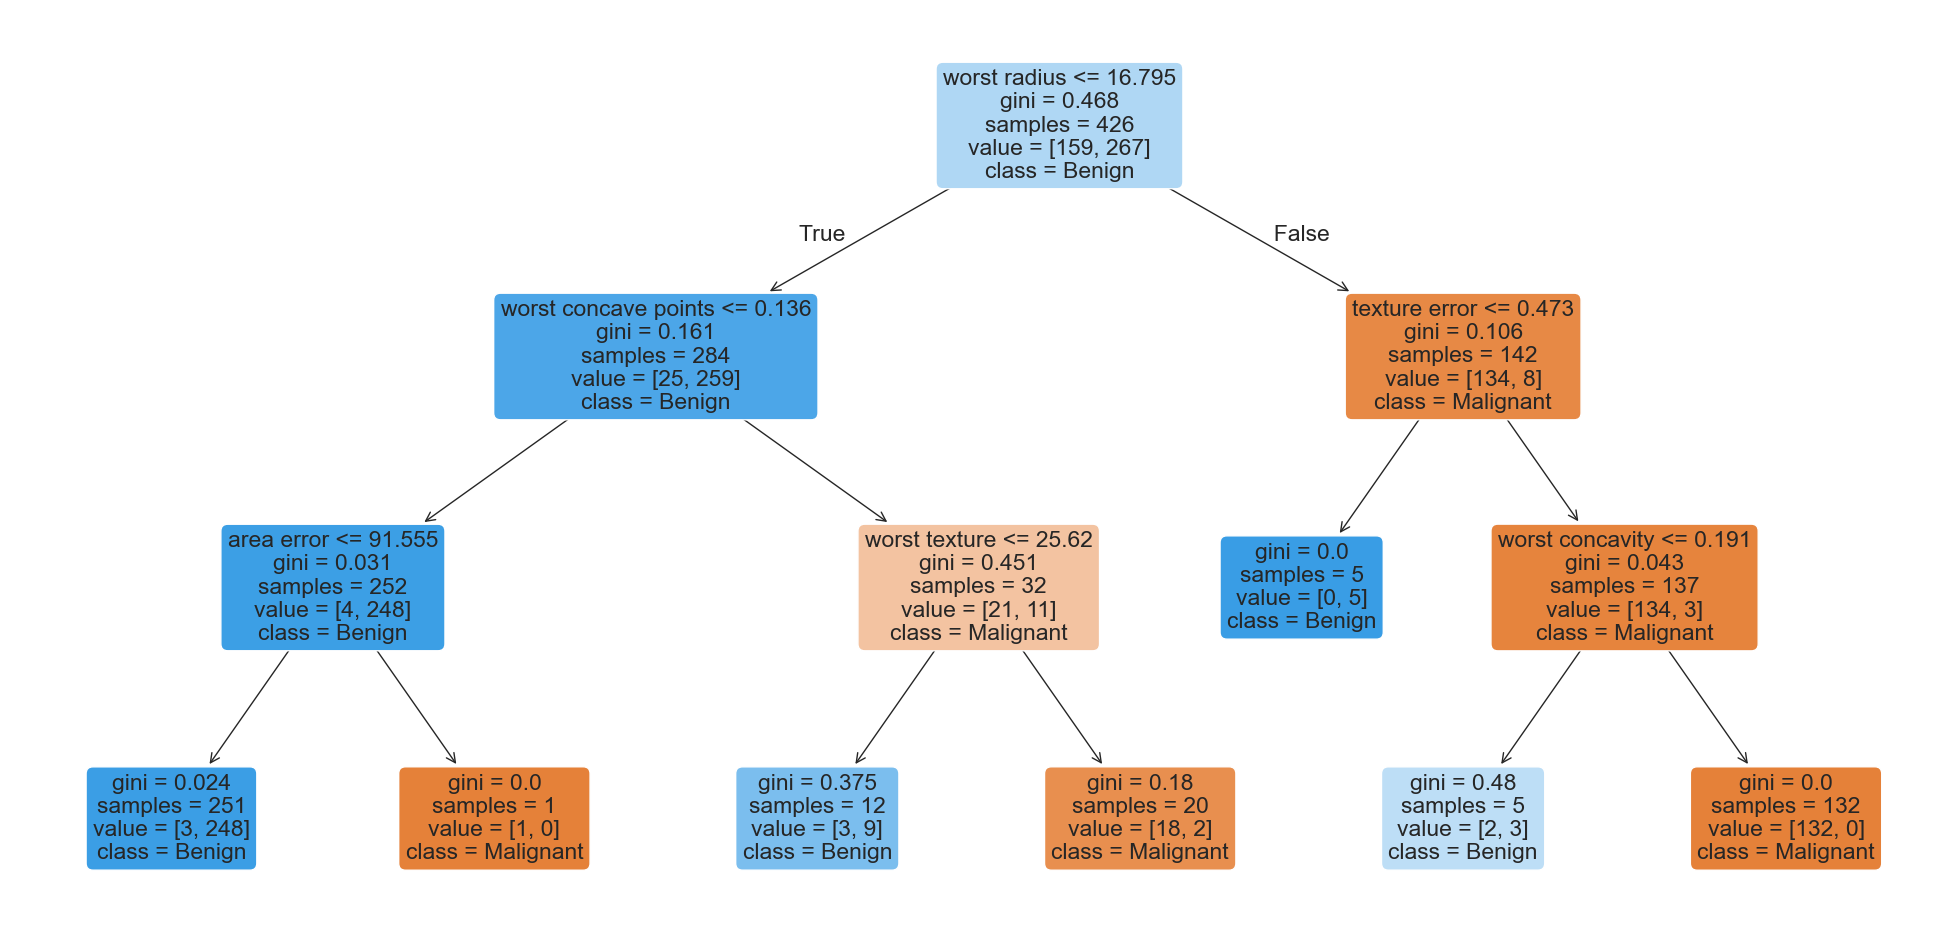


Dac trung duoc dung de chia tach du lieu tai nut goc: worst radius
Dac trung dong gop lon nhat: worst radius (75.79%)


In [5]:
# TODO 4a: Khởi tạo và huấn luyện Decision Tree
dt_model = DecisionTreeClassifier(max_depth = 3, random_state = 42)
dt_model.fit(X_train, y_train)

# TODO 4b: Vẽ cấu trúc Decision Tree
plt.figure(figsize = (25,12))
plot_tree(dt_model, feature_names = cancer_data.feature_names, class_names = ['Malignant', 'Benign'], filled = True, rounded = True)
plt.show()

# In ra tên đặc trưng được dùng để chia nhánh dữ liệu đầu tiên tại nút gốc
feature_index = dt_model.tree_.feature[0]
root_feature_split = cancer_data.feature_names[feature_index]
print("\nDac trung duoc dung de chia tach du lieu tai nut goc:", root_feature_split)

# Tìm đặc trưng đóng góp nhiều nhất trong tổng quá trình phân chia
importance_feature_index = np.argmax(dt_model.feature_importances_)
best_feature = cancer_data.feature_names[importance_feature_index]
best_score = dt_model.feature_importances_[importance_feature_index]

print(f"Dac trung dong gop lon nhat: {best_feature} ({best_score * 100:.2f}%)")

**Nhận xét Task 4:**

- Nút gốc (Root Node) của cây sử dụng đặc trưng **worst radius** để phân tách dữ liệu. Từ đó: giá trị Gini giảm mạnh từ 0.468, xuống còn Gini = 0.161 (nhánh trái) và Gini = 0.106 (nhánh phải).
- Tuy nhiên, chưa chắc **worst radius** là đặc trưng quan trọng nhất . Decision Tree đơn lẻ chỉ chọn đặc trưng tốt nhất (Giá trị weighted gini index nhỏ nhất trong các đặc trưng) tại một điểm chia cụ thể, nên nó có thể nhạy cảm với nhiễu,... và không phản ánh đầy đủ mức độ quan trọng trung bình của đặc trưng trên nhiều kịch bản dữ liệu khác nhau.

---
## Task 5 — Rừng Ngẫu Nhiên & Độ Quan Trọng của Đặc Trưng

### Yêu cầu:
1. Khởi tạo và huấn luyện `RandomForestClassifier(n_estimators=100, random_state=42)`.
2. Lấy ra mức độ quan trọng của từng đặc trưng (`feature_importances_`).
3. Vẽ biểu đồ **Bar plot ngang (Horizontal Barplot)** hiển thị **Top 10 đặc trưng quan trọng nhất** theo đánh giá của Random Forest.

### Gợi ý:
- Tạo DataFrame để dễ dàng sắp xếp: `imp_df = pd.DataFrame({'Feature': cancer_data.feature_names, 'Importance': rf_model.feature_importances_})`.
- Sắp xếp giảm dần: `imp_df = imp_df.sort_values(by='Importance', ascending=False)`.
- Lấy 10 dòng đầu (`.head(10)`) và đưa vào hàm `sns.barplot(data=..., x='Importance', y='Feature')` để vẽ.

                 Feature  Importance
23            worst area       0.150
27  worst concave points       0.127
7    mean concave points       0.105
20          worst radius       0.087
22       worst perimeter       0.080
2         mean perimeter       0.080
6         mean concavity       0.055
0            mean radius       0.054
3              mean area       0.044
13            area error       0.025


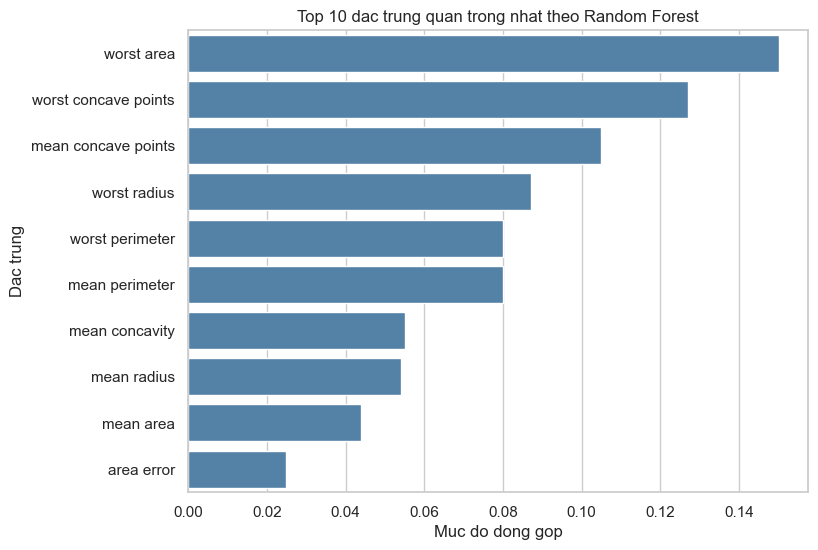

In [7]:
# TODO 5a: Huấn luyện Random Forest
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf_model.fit(X_train_scaled, y_train)

# TODO 5b: Trích xuất và trực quan hóa Top 10 Feature Importances
importances = rf_model.feature_importances_

# DataFrame
imp_df = pd.DataFrame({
    'Feature': cancer_data.feature_names,
    'Importance': importances
})
imp_df = imp_df.sort_values(by = 'Importance', ascending = False)

# Lấy 10 đặc trưng quan trọng nhất
top_ten_features = imp_df.head(10).round(3)
print(top_ten_features)

# Trực quan hoá
plt.figure(figsize = (8 , 6))
sns.barplot(data = top_ten_features, x = 'Importance', y = 'Feature', color = "steelblue")
plt.xlabel("Muc do dong gop")
plt.ylabel("Dac trung")
plt.title("Top 10 dac trung quan trong nhat theo Random Forest")
plt.show()

---
## Task 6 — Đánh giá Mô Hình chuyên sâu (Confusion Matrix, Recall, F1)

Trong bài toán này:
*   **Class 0 (Malignant - Ác tính)** là lớp chúng ta cực kỳ muốn tìm ra.
*   **Class 1 (Benign - Lành tính)** là lớp ít nguy hiểm hơn.

**Recall của lớp 0** cho biết: Trong tổng số những người thực sự mắc bệnh ung thư ác tính, mô hình đã "bắt" được bao nhiêu phần trăm?

### Yêu cầu:
1. Dự đoán trên tập Test bằng mô hình Random Forest ở Task 5.
2. Vẽ **Confusion Matrix**.
3. In `classification_report` và phân tích kết quả của `Recall` và `F1-Score` đặc biệt cho lớp 0 (Malignant).
4. Mô hình hiện tại của bạn đã bỏ sót bao nhiêu bệnh nhân có khối u ác tính trên tập Test (False Negative)? Con số này đã đủ tốt để triển khai thực tế chưa?

### Gợi ý:
- Lệnh dự đoán: `y_pred_rf = rf_model.predict(X_test_scaled)`.
- Dùng hàm `confusion_matrix(y_test, y_pred_rf)` kết hợp với `ConfusionMatrixDisplay` (đã import ở ô đầu tiên) để vẽ.
- Cần cẩn thận khi đọc Confusion Matrix: Dựa vào các trục Thực tế (True label) và Dự đoán (Predicted label), hãy nhìn vào ô có `Thực tế = 0` nhưng `Dự đoán = 1` để tìm số ca bị bỏ sót.

Classification Report:
              precision    recall  f1-score   support

Malignant(0)       0.96      0.92      0.94        53
   Benign(1)       0.96      0.98      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143



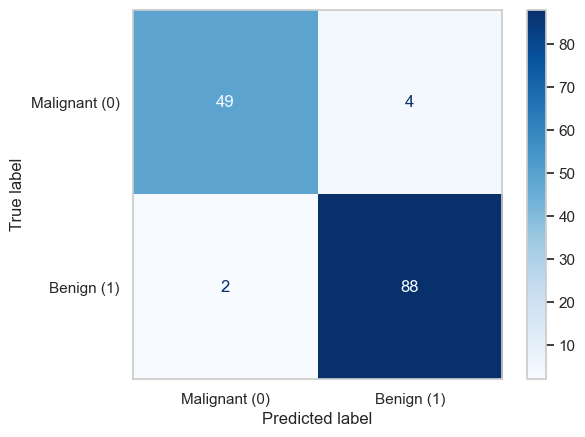

In [8]:
# TODO 6a: Dự đoán trên Test set
y_pred_rf = rf_model.predict(X_test_scaled)

# TODO 6b: In Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names = ['Malignant(0)', 'Benign(1)']))

# TODO 6c: Vẽ Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm, display_labels=['Malignant (0)', 'Benign (1)'])
disp.plot(cmap = 'Blues')
plt.grid(False)
plt.show()

**Đánh giá Task 6 (Business/Medical Insight):**
1. Recall của lớp Ác tính (0) là bao nhiêu? F1-Score là bao nhiêu?
2. Nhìn vào Confusion Matrix, số bệnh nhân bị bỏ sót (thực tế Ác tính nhưng dự đoán Lành tính) là bao nhiêu ca?
3. Nếu bạn là bác sĩ, bạn thà đánh đổi (giảm Precision để tăng Recall) hay muốn giữ độ chuẩn xác chung? Vì sao?

> Trả lời
1. Trên tập Test (143 mẫu), giá trị **Recall** và **F1-Score** của lớp **Ác tính (0)** đạt khoảng **0.92** và F1-Score lớp 0 khoảng **0.94**. Điều này có nghĩa là trong số các bệnh nhân thực sự mang khối u ác tính, mô hình chỉ "bắt" đúng được khoảng 92%, còn lại khoảng 8% bị bỏ sót.

2. Nhìn vào Confusion Matrix: Trong tổng số **53 ca thực tế** là **Ác tính** trên tập Test, mô hình dự đoán đúng 49 ca nhưng dự đoán nhầm thành Lành tính **4 ca**. Ở chiều ngược lại, mô hình cũng có 2 trường hợp mà thực tế Lành tính nhưng dự đoán nhầm thành Ác tính.

3. Trong bài toán chẩn đoán ung thư, **nên ưu tiên tăng Recall của lớp Ác tính hơn, kể cả nếu phải đánh đổi giảm Precision**. Bời vì chi phí của một False Negative (bỏ sót bệnh nhân ung thư thực sự) là rất lớn — chậm trễ trong việc điều trị khiến bệnh tiến triển nặng hơn và giảm khả năng điều trị khỏi. Chi phí đó lớn hơn rất nhiều so với chi phí của một False Positive (chẩn đoán nhầm người khỏe mạnh thành có bệnh) — bệnh nhân phải làm thêm xét nghiệm thêm để xác nhận lại, gây tốn kém và lo lắng nhưng không nguy hiểm đến tính mạng.